In [2]:
import pandas as pd

train = pd.read_csv(r"D:\sem project\train.csv")
print(train.head())
print(train.info())

   date_id  D1  D2  D3  D4  D5  D6  D7  D8  D9  ...  V3  V4  V5  V6  V7  V8  \
0        0   0   0   0   1   1   0   0   0   1  ... NaN NaN NaN NaN NaN NaN   
1        1   0   0   0   1   1   0   0   0   1  ... NaN NaN NaN NaN NaN NaN   
2        2   0   0   0   1   0   0   0   0   1  ... NaN NaN NaN NaN NaN NaN   
3        3   0   0   0   1   0   0   0   0   0  ... NaN NaN NaN NaN NaN NaN   
4        4   0   0   0   1   0   0   0   0   0  ... NaN NaN NaN NaN NaN NaN   

   V9  forward_returns  risk_free_rate  market_forward_excess_returns  
0 NaN        -0.002421        0.000301                      -0.003038  
1 NaN        -0.008495        0.000303                      -0.009114  
2 NaN        -0.009624        0.000301                      -0.010243  
3 NaN         0.004662        0.000299                       0.004046  
4 NaN        -0.011686        0.000299                      -0.012301  

[5 rows x 98 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9021 entries, 0 to 9

In [4]:
train = train.ffill().fillna(0)


In [6]:
target = train["forward_returns"]


In [8]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X = train.drop(columns=["forward_returns", "risk_free_rate", "market_forward_excess_returns"])
y = train["forward_returns"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
)
model.fit(X_train, y_train)
preds = model.predict(X_val)

print("Validation MSE:", mean_squared_error(y_val, preds))


Validation MSE: 0.00015977830787296417


In [12]:
allocations = 1 + preds / preds.std()
allocations = allocations.clip(0, 2)

In [20]:
test = pd.read_csv(r"D:\sem project\test.csv")


In [32]:
submission = pd.DataFrame({
    "date_id": test["date_id"],
    "allocation": allocations[:len(test)]  # trims if needed
})
submission.to_csv("submission.csv", index=False)
print("✅ Submission file created successfully!")


✅ Submission file created successfully!


In [34]:
print(allocations)


[1.1737763  0.08046597 0.31275946 0.         0.         0.42282188
 1.6315299  0.9205561  0.         0.        ]


In [36]:
import pandas as pd
pd.Series(allocations).head(10)


0    1.173776
1    0.080466
2    0.312759
3    0.000000
4    0.000000
5    0.422822
6    1.631530
7    0.920556
8    0.000000
9    0.000000
dtype: float32

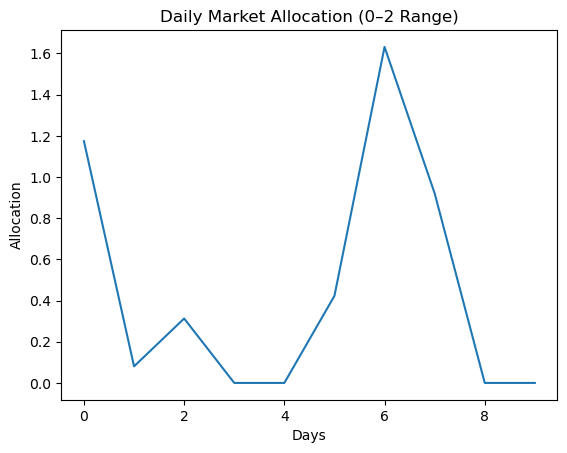

In [38]:
import matplotlib.pyplot as plt

plt.plot(allocations)
plt.title("Daily Market Allocation (0–2 Range)")
plt.xlabel("Days")
plt.ylabel("Allocation")
plt.show()
